# Zipf Figures

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import textgrids
from pathlib import Path
import re
from pathlib import Path

In [2]:
def get_words(txt_dir, align_type="words"):
    tg_files = list(Path(txt_dir).rglob("*.TextGrid"))
    text = []

    for tg_path in tg_files:
        tg = textgrids.TextGrid(str(tg_path))
        tier = tg[align_type]

        for interval in tier:
            label = interval.text.strip().lower()
            if label in ["", "<unk>", "sp", "sil", "spn"]:
                continue
            #  remove numbers and decimals
            label = re.sub(r'\d+', '', label)
            text.append(label)
    
    if align_type == "phones":
        text = [re.sub(r'\d+', '', phn) for phn in text]

    return text

def get_clusters(partition_path):
    clusters = []
    current_cluster = []
    
    with open(partition_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            
            if len(parts) == 3:
                current_cluster.append(tuple(parts))
            
            elif len(parts) == 2 and current_cluster:
                clusters.append(current_cluster)
                current_cluster = [] 
                
        if current_cluster:
            clusters.append(current_cluster)

    return clusters

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 7,
})


### dev-clean words: K-means vs Gold

Saving figures to: figs/LibriSpeech/dev-clean


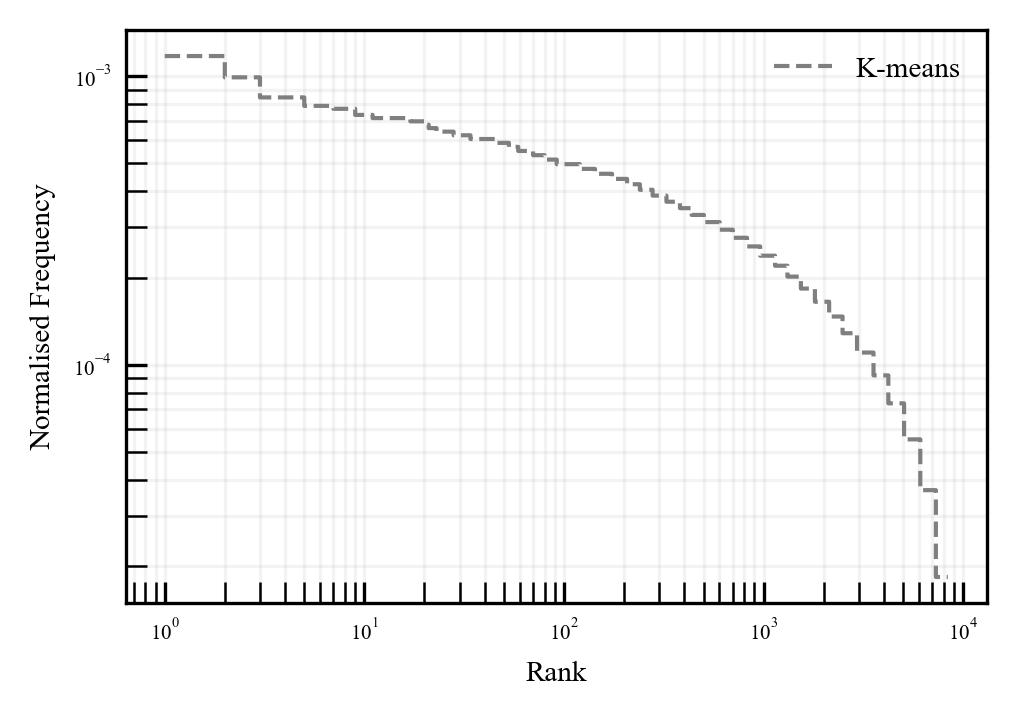

In [ ]:

dataset_dir = Path("../data/alignments/LibriSpeech/dev-clean_feature_sliced/")
kmeans_path = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/fbgmm/kmeans_k8372_269.82.txt")

gt_items = get_words(dataset_dir, align_type="words")
kmeans_clusters = get_clusters(kmeans_path)

dataset = kmeans_path.parts[1]
dataset_subset = kmeans_path.parts[2].split("_")[0]
fig_dir = Path("figs") / dataset / dataset_subset
fig_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving figures to: {fig_dir}")

legend_handles = {}
fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=300)

# Ground truth distribution
# gt_counts = Counter(gt_items)
# gt_freqs = np.array(sorted(gt_counts.values(), reverse=True))
# gt_probs = gt_freqs / gt_freqs.sum()
# gt_ranks = np.arange(1, len(gt_probs) + 1)

# line, = ax.loglog(
#     gt_ranks,
#     gt_probs,
#     linestyle="-",
#     color="black",
#     linewidth=1,
#     drawstyle="steps-post",
#     label="Ground truth",
#     zorder=3,
# )
# legend_handles.setdefault("Gold", line)

# global_max_freq = gt_probs[0]
# global_max_rank = len(gt_probs)
global_max_freq = 0
global_max_rank = 0

# K-means
cluster_sizes = np.array(sorted([len(c) for c in kmeans_clusters], reverse=True))
probs = cluster_sizes / cluster_sizes.sum()
ranks = np.arange(1, len(probs) + 1)

line, = ax.loglog(
        ranks,
        probs,
        label="K-means",
        color='tab:gray',
        linewidth=1,
        drawstyle="steps-post",
        linestyle="--",
    )

legend_handles.setdefault("K-means", line)  

ax.set_xlabel("Rank")
ax.set_ylabel("Normalised Frequency")

global_max_freq = max(global_max_freq, probs[0])
global_max_rank = max(global_max_rank, len(probs))

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction="in", which="both", length=5)

legend_order = ["Gold", "K-means"]
ax.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="best",
    frameon=False,
)
plt.tight_layout()
# plt.savefig(
#     fig_dir / f"zipf_plot_words_{dataset_subset}.pdf",
#     bbox_inches="tight",
# )
plt.show()